In [2]:

import numpy as np
import pandas as pd


col_id = ['dac_family'
    'day'
    'hour'
]
col_dn = [
    'dn_count',
    'dn_notvalid_count',
    'dn_ok_count',
    'dn_nxd_count',
    'dn_nxd_notvalid_count'
]
col_dn += [ 'p1_' + c for c in col_dn ]
col_total = [
    'qr',
    'q',
    'ok',
    'nx',
    'qr_notvalid',
    'q_notvalid',
    'nx_notvalid',
    'fa',
    'fa_ok',
    'fa_nx',
    'macfa',
    'macfa_ok',
    'macfa_nx'
]
col_p1 = [ 'p1_' + c for c in col_total]
col_llr = [ 'llr1_' + c for c in col_total]

col_numeric = col_dn + col_total + col_p1 + col_llr
col_malicious = col_total + col_p1 + col_llr
col_malicious = col_total + col_p1 + col_llr

col_features = ['hour'] + col_dn + col_total + col_p1 + col_llr

DATASET = pd.read_csv('dataset.csv', index_col=[0,1,2])
DATASET = DATASET.fillna(0).replace(np.inf, 50).replace(-np.inf, -50)
DATASET

label  dn_count  dn_notvalid_count  dn_ok_count  \
day hour dac_family                                                    
0   0    healthy       0.0   56058.0             2650.0      52642.0   
         modpack       1.0   56059.0             2650.0      52643.0   
         necurs        1.0   60063.0             2650.0      54892.0   
         virut         1.0   56059.0             2650.0      52643.0   
    1    conficker     1.0   47938.0             2112.0      45687.0   
...                    ...       ...                ...          ...   
9   22   suppobox      1.0   63292.0            63292.0      63292.0   
    23   virut         1.0   59299.0            59299.0      59299.0   
         conficker     1.0   59299.0            59299.0      59299.0   
         pitou         1.0   59299.0            59299.0      59299.0   
         suppobox      1.0   59299.0            59299.0      59299.0   

                     dn_nxd_count  dn_nxd_notvalid_count          qr  \
day hour dac_family                                                    
0   0    healthy           2829.0                 1296.0  16758780.0   
         modpack           2829.0                 1296.0       310.0   
         necurs            4453.0                 1296.0    687370.0   
         virut             2829.0                 1296.0        10.0   
    1    conficker         2103.0                 1076.0     22040.0   
...                           ...                    ...         ...   
9   22   suppobox         63292.0                63292.0     63292.0   
    23   virut            59299.0                59299.0     59299.0   
         conficker        59299.0                59299.0     59299.0   
         pitou            59299.0                59299.0     59299.0   
         suppobox         59299.0                59299.0     59299.0   

                             q          ok        nx  ...    llr1_fa_ok  \
day hour dac_family                                   ...                 
0   0    healthy     8032350.0  15999260.0  473260.0  ...     50.000000   
         modpack         140.0       310.0       0.0  ...    -16.264704   
         necurs       191990.0    340010.0  311840.0  ...     50.000000   
         virut             0.0        10.0       0.0  ...    -22.253365   
    1    conficker      5880.0     13210.0    8600.0  ...   2972.304672   
...                        ...         ...       ...  ...           ...   
9   22   suppobox      63292.0     63292.0   63292.0  ...  63292.000000   
    23   virut         59299.0     59299.0   59299.0  ...  59299.000000   
         conficker     59299.0     59299.0   59299.0  ...  59299.000000   
         pitou         59299.0     59299.0   59299.0  ...  59299.000000   
         suppobox      59299.0     59299.0   59299.0  ...  59299.000000   

                       llr1_fa_nx    llr1_macfa  llr1_macfa_ok  llr1_macfa_nx  \
day hour dac_family                                                             
0   0    healthy        50.000000     50.000000      50.000000      50.000000   
         modpack         0.000000    -24.397056     -32.529408       0.000000   
         necurs         50.000000     50.000000      50.000000      50.000000   
         virut           0.000000    -22.253365     -22.253365       0.000000   
    1    conficker    1663.399606   6830.362379    5253.226402    4261.997072   
...                           ...           ...            ...            ...   
9   22   suppobox    63292.000000  63292.000000   63292.000000   63292.000000   
    23   virut       59299.000000  59299.000000   59299.000000   59299.000000   
         conficker   59299.000000  59299.000000   59299.000000   59299.000000   
         pitou       59299.000000  59299.000000   59299.000000   59299.000000   
         suppobox    59299.000000  59299.000000   59299.000000   59299.000000   

                     p1_dn_count  p1_dn_notvalid_count  p1_dn_ok_count  \
day hour dac_family                        

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt
import warnings

from sklearn.svm import OneClassSVM
warnings.simplefilter(action='ignore', category=FutureWarning)


DATASET = pd.read_csv('dataset.csv', index_col=[0,1,2])
DATASET = DATASET.fillna(0).replace(np.inf, 50).replace(-np.inf, -50)
DATASET = DATASET.drop(columns=col_llr).reset_index('hour')

# D0 = DATASET.loc[pd.IndexSlice[(0, 1), ('healthy',)], :]
# D1 = DATASET.loc[pd.IndexSlice[(2, 3), 'healthy+conficker'], :]

TRAIN = DATASET.loc[pd.IndexSlice[list(range(4)), 'healthy+conficker'], :]
y = TRAIN['label']
X = TRAIN.drop(columns='label')

# ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
# ocsvm.fit(X, y)
# sfs1 = SFS(ocsvm,
#            k_features=5, 
#            forward=True, 
#            floating=False, 
#            verbose=2,
#            scoring='accuracy',
#            cv=5)
# sfs1 = sfs1.fit(X, y)


rf = RandomForestClassifier()
sfs1 = SFS(rf,
           k_features=5, 
           forward=True, 
           floating=False, 
           verbose=2,
           scoring='accuracy',
           cv=5)
sfs1 = sfs1.fit(X, y)

# print('Best accuracy score: %.2f' % sfs1.k_score_)
# print('Best subset (indices):', sfs1.k_feature_idx_)
# print('Best subset (corresponding names):', sfs1.k_feature_names_)

# fig1 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')

# plt.title('Sequential Forward Selection (w. StdDev)')
# plt.grid()
# plt.show()


[2024-11-30 14:16:48] Features: 1/5 -- score: 1.0
[2024-11-30 14:16:54] Features: 2/5 -- score: 1.0
[2024-11-30 14:17:00] Features: 3/5 -- score: 1.0
[2024-11-30 14:17:06] Features: 4/5 -- score: 1.0
[2024-11-30 14:17:12] Features: 5/5 -- score: 1.0

KeyError: (0, 1, 2, 3, 4)

In [357]:
import itertools

sreports = {}

mws = ['healthy+conficker', 'healthy+modpack', 'healthy+necurs', 'healthy+pitou', 'healthy+suppobox', 'healthy+virut']

for mw in mws:
    sreports[mw] = {}

    print(mw)

    DATASET = pd.read_csv('dataset.csv', index_col=[0,1,2])
    DATASET = DATASET.fillna(0).replace(np.inf, 50).replace(-np.inf, -50)
    DATASET = DATASET.drop(columns=col_llr).reset_index('hour')

    TRAIN = DATASET.loc[pd.IndexSlice[list(range(4)), mw], :]
    y = TRAIN['label']
    X = TRAIN.drop(columns='label')

    rf = RandomForestClassifier()
    sfs1 = SFS(rf,
            k_features="best", 
            forward=False, 
            floating=False, 
            verbose=0,
            scoring='accuracy',
            cv=3)
    sfs1 = sfs1.fit(X, y)

    sreports[mw]['sfs'] = sfs1
    sreports[mw]['features'] = list(sfs1.k_feature_names_)
    sreports[mw]['score'] = sfs1.k_score_

    TRAIN = TRAIN[list(sfs1.k_feature_names_)]

    rf = RandomForestClassifier()
    rf.fit(TRAIN, y)

    for mw2 in ['healthy+conficker', 'healthy+modpack', 'healthy+necurs', 'healthy+pitou', 'healthy+suppobox', 'healthy+virut']:
        TEST = DATASET.loc[pd.IndexSlice[list(range(4, 10)), mw2], :]
        y_test = TEST['label']
        X_test = TEST.drop(columns='label')

        y_pred = rf.predict(X_test[list(sfs1.k_feature_names_)])

        report = classification_report(y_test, y_pred)
        sreports[mw][mw2] = classification_report(y_test, y_pred, output_dict=True)

        # print('trained in ', mw, 'tested in ', mw2)
        pass
    pass


healthy+conficker
healthy+modpack
healthy+necurs
healthy+pitou
healthy+suppobox


/Users/princio/Repo/princio/malware-detection-predict-file/web/mwdb/pybackend/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/princio/Repo/princio/malware-detection-predict-file/web/mwdb/pybackend/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/princio/Repo/princio/malware-detection-predict-file/web/mwdb/pybackend/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0

healthy+virut


['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count', 'dn_nxd_notvalid_count', 'qr', 'q', 'ok', 'nx', 'qr_notvalid', 'q_notvalid', 'nx_notvalid', 'fa', 'fa_ok', 'fa_nx', 'macfa', 'macfa_ok', 'macfa_nx', 'p1_qr', 'p1_q', 'p1_ok', 'p1_nx', 'p1_qr_notvalid', 'p1_q_notvalid', 'p1_nx_notvalid', 'p1_fa', 'p1_fa_ok', 'p1_fa_nx', 'p1_macfa', 'p1_macfa_ok', 'p1_macfa_nx', 'p1_dn_count', 'p1_dn_notvalid_count', 'p1_dn_ok_count', 'p1_dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count', 'dn_nxd_notvalid_count', 'qr', 'q', 'ok', 'nx', 'qr_notvalid', 'q_notvalid', 'nx_notvalid', 'fa', 'fa_ok', 'fa_nx', 'macfa', 'macfa_ok', 'macfa_nx', 'p1_qr', 'p1_q', 'p1_ok', 'p1_nx', 'p1_qr_notvalid', 'p1_q_notvalid', 'p1_nx_notvalid', 'p1_fa', 'p1_fa_ok', 'p1_fa_nx', 'p1_macfa', 'p1_macfa_ok', 'p1_macfa_nx', 'p1_dn_count', 'p1_dn_notvalid_count', 'p1_dn_ok_count', 'p1_dn_nxd_count', 'p1_dn_nxd_notvalid_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_c

conficker                                               modpack  \
                tpr support pos-support   fpr support neg-support     tpr   
conficker      1.00   48/48        48.0  0.00    0/96        96.0    0.32   
modpack        0.88   42/48        48.0  0.94   90/96        96.0    1.00   
necurs         0.75   36/48        48.0  0.88   84/96        96.0    0.91   
pitou          0.12    6/48        48.0  0.12   12/96        96.0    0.14   
suppobox       0.00    0/48        48.0  0.06    6/96        96.0    0.05   
virut          0.38   18/48        48.0  0.31   30/96        96.0    0.36   

                                     ...    suppobox                 \
           support pos-support  fpr  ... pos-support   fpr  support   
conficker   42/132       132.0  0.5  ...         6.0  0.35   48/138   
modpack    132/132       132.0  0.0  ...         6.0  0.91  126/138   
necurs     120/132       132.0  0.0  ...         6.0  0.83  114/138   
pitou       18/132       132.0  0.0  ...         6.0  0.13   18/138   
suppobox     6/132       132.0  0.0  ...         6.0  0.00    0/138   
virut       48/132       132.0  0.0  ...         6.0  0.35   48/138   

                      virut                                                
          neg-support   tpr support pos-support   fpr support neg-support  
conficker       138.0  0.38   18/48        48.0  0.31   30/96        96.0  
modpack         138.0  1.00   48/48        48.0  0.88   84/96        96.0  
necurs          138.0  1.00   48/48        48.0  0.75   72/96        96.0  
pitou           138.0  0.38   18/48        48.0  0.00    0/96        96.0  
suppobox        138.0  0.00    0/48        48.0  0.06    6/96        96.0  
virut           138.0  1.00   48/48        48.0  0.00    0/96        96.0  

[6 rows x 36 columns]

\begin{tabular}{lrrrrrr}
\toprule
 & conficker & modpack & necurs & pitou & suppobox & virut \\
\midrule
neg-support & 96 & 12 & 18 & 126 & 138 & 96 \\
pos-support & 48 & 132 & 126 & 18 & 6 & 48 \\
\bottomrule
\end{tabular}



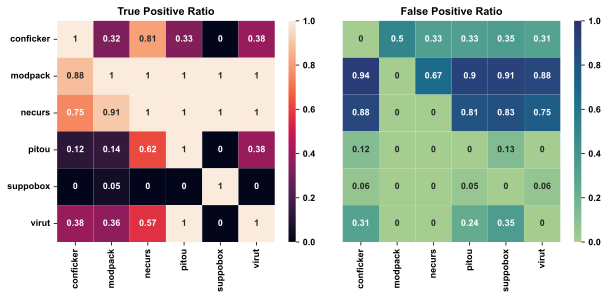

In [358]:

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
import seaborn as sns
%matplotlib inline

index = []
values = []
for trainer in sreports:
    columns = []
    row = []
    index.append(trainer.replace('healthy+', ''))
    print(sreports[trainer]['features'])
    for tester in sreports[trainer]:
        if tester in ['sfs', 'features', 'score']: continue
        label = tester.replace('healthy+', '')
        d = sreports[trainer][tester]
        columns.append((label, 'tpr'))
        row.append(round(d['1.0']['recall'], 2))
        columns.append((label, 'support'))
        row.append(f'{int(d['1.0']['recall'] * d['1.0']['support'])}/{int(d['1.0']['support'])}')
        columns.append((label, 'pos-support'))
        row.append(d['1.0']['support'])

        columns.append((label, 'fpr'))
        row.append(round(1 - d['0.0']['recall'], 2))
        columns.append((label, 'support'))
        row.append('%d/%d' % (int((1.0 - d['0.0']['recall']) * d['0.0']['support']), d['0.0']['support']))
        columns.append((label, 'neg-support'))
        row.append(d['0.0']['support'])
    values.append(row)

df = pd.DataFrame(values, columns=pd.MultiIndex.from_tuples(columns), index=index)

display(df)

df = df.sort_index()
support = df.loc[:, pd.IndexSlice[:, ('pos-support', 'neg-support')]].drop_duplicates()
support = support.stack().droplevel(0, axis=0).astype(int)
print(support.to_latex())

fig, axs = plt.subplots(1, 2, figsize=(10,4), gridspec_kw=dict(width_ratios=[1,1]))
tpr = df.loc[:, pd.IndexSlice[:, 'tpr']]
tpr = tpr.droplevel(1, axis=1)

fpr = df.loc[:, pd.IndexSlice[:, 'fpr']]
fpr = fpr.droplevel(1, axis=1)

axs[0].set_title('True Positive Ratio', size='large', family='arial', weight='bold')
sns.heatmap(tpr, annot=True, yticklabels=True, cbar=True, ax=axs[0], vmin=0., vmax=1., cbar_kws=dict(aspect=30))
axs[1].set_title('False Positive Ratio', size='large', family='arial', weight='bold')
sns.heatmap(fpr, annot=True, yticklabels=False, cmap='crest', cbar=True, ax=axs[1], vmin=0., vmax=1., cbar_kws=dict(aspect=30))
# fig.colorbar(axs[1].collections[0], cax=axs[2])

plt.gcf().subplots_adjust(hspace=0.1, wspace=0.05)

plt.gcf().savefig(f'plot_single.pdf', bbox_inches='tight')

# Multiple trainers

In [ ]:
import itertools

reports = {}

mws = ['healthy+conficker', 'healthy+modpack', 'healthy+necurs', 'healthy+pitou', 'healthy+suppobox', 'healthy+virut']
couples = list(set((itertools.product(mws, mws))))

for mw in couples:
    reports[mw] = {}

    print(mw)

    DATASET = pd.read_csv('dataset.csv', index_col=[0,1,2])
    DATASET = DATASET.fillna(0).replace(np.inf, 50).replace(-np.inf, -50)
    DATASET = DATASET.drop(columns=col_llr).reset_index('hour')

    TRAIN0 = DATASET.loc[pd.IndexSlice[list(range(4)), mw[0]], :]
    TRAIN1 = DATASET.loc[pd.IndexSlice[list(range(4)), mw[1]], :]
    TRAIN = pd.concat([TRAIN0, TRAIN1])

    y = TRAIN['label']
    X = TRAIN.drop(columns='label')

    rf = RandomForestClassifier()
    sfs1 = SFS(rf,
            k_features=5, 
            forward=True, 
            floating=False, 
            verbose=2,
            scoring='accuracy',
            cv=3)
    sfs1 = sfs1.fit(X, y)

    reports[mw]['sfs'] = sfs1
    reports[mw]['features'] = list(sfs1.k_feature_names_)
    reports[mw]['score'] = sfs1.k_score_

    TRAIN = TRAIN[list(sfs1.k_feature_names_)]

    rf = RandomForestClassifier()
    rf.fit(TRAIN, y)

    for mw2 in ['healthy+conficker', 'healthy+modpack', 'healthy+necurs', 'healthy+pitou', 'healthy+suppobox', 'healthy+virut']:
        TEST = DATASET.loc[pd.IndexSlice[list(range(4, 10)), mw2], :]
        y_test = TEST['label']
        X_test = TEST.drop(columns='label')

        y_pred = rf.predict(X_test[list(sfs1.k_feature_names_)])

        report = classification_report(y_test, y_pred)
        reports[mw][mw2] = classification_report(y_test, y_pred, output_dict=True)

        print('trained in ', mw, 'tested in ', mw2)
        print(report)
        pass
    pass


['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_notvalid_count', 'fa_ok']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['dn_count', 'qr', 'nx_notvalid', 'p1_nx', 'p1_fa']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_nxd_notvalid_count', 'fa_ok']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_notvalid_count', 'fa_ok']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 'dn_nxd_count']
['hour', 'dn_count', 'dn_notvalid_count', 'dn_ok_count', 

,conficker,modpack,necurs,pitou,suppobox,virut
neg-support,96,12,18,126,138,96
pos-support,48,132,126,18,6,48


\begin{tabular}{lrrrrrr}
\toprule
 & conficker & modpack & necurs & pitou & suppobox & virut \\
\midrule
neg-support & 96 & 12 & 18 & 126 & 138 & 96 \\
pos-support & 48 & 132 & 126 & 18 & 6 & 48 \\
\bottomrule
\end{tabular}



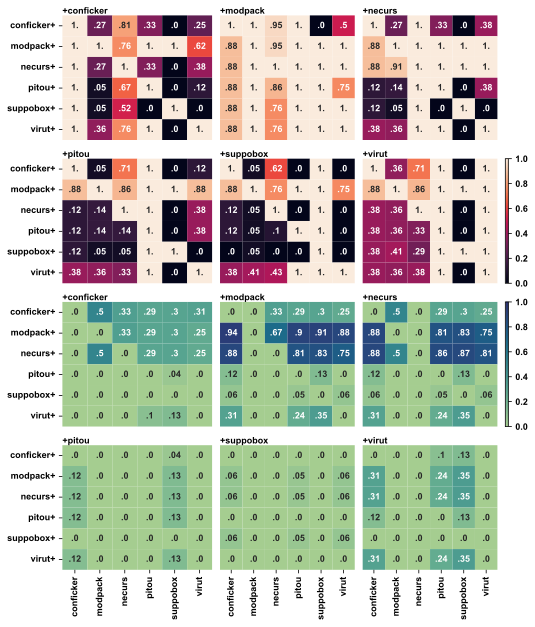

In [331]:

import matplotlib
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
import seaborn as sns
%matplotlib inline

index = []
values = []
for trainer in reports:
    columns = []
    row = []
    index.append((trainer[0].replace('healthy+', ''), trainer[1].replace('healthy+', '')))
    print(reports[trainer]['features'])
    for tester in reports[trainer]:
        if tester in ['sfs', 'features', 'score']: continue
        label = tester.replace('healthy+', '')
        d = reports[trainer][tester]
        columns.append((label, 'tpr'))
        row.append(round(d['1.0']['recall'], 2))
        columns.append((label, 'pos'))
        row.append(f'{int(d['1.0']['recall'] * d['1.0']['support'])}/{int(d['1.0']['support'])}')
        columns.append((label, 'pos-support'))
        row.append(int(d['1.0']['support']))

        columns.append((label, 'fpr'))
        row.append(round(1 - d['0.0']['recall'], 2))
        columns.append((label, 'neg'))
        row.append('%d/%d' % (int((1.0 - d['0.0']['recall']) * d['0.0']['support']), d['0.0']['support']))

        columns.append((label, 'neg-support'))
        row.append(int(d['0.0']['support']))

        pass

    values.append(row)

df = pd.DataFrame(values, columns=pd.MultiIndex.from_tuples(columns), index=pd.MultiIndex.from_tuples(index))

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 9}

matplotlib.rc('font', **font)

# sns.heatmap(df.loc[:, pd.IndexSlice[:, 'tpr']], annot=True)
# df.loc[:, pd.IndexSlice[:, 'tpr']].plot.heatmap()
df = df.sort_index()

support = df.loc[pd.IndexSlice[:, :], pd.IndexSlice[:, ('pos-support', 'neg-support')]].drop_duplicates()

support = support.stack().droplevel([0,1], axis=0)

display(support)
print(support.to_latex())

fig, axs = plt.subplots(4, 4, figsize=(8,10), gridspec_kw=dict(width_ratios=[1,0.9,0.9,0.02]))
for idx, mw in enumerate(mws):
    ax = axs[idx // 3, idx % 3]
    mw = mw.replace('healthy+', '')
    ax.set_title('+' + mw, size='medium', family='arial', weight='bold', loc='left', pad=-2)
    x = df.loc[pd.IndexSlice[mw, :], :]
    annot=x.loc[:, pd.IndexSlice[:, 'tpr']].applymap(lambda x: str(x)[1:] if x < 1 else '1.')
    x = x.loc[:, pd.IndexSlice[:, 'tpr']].droplevel(0, axis=0).droplevel(1, axis=1)
    x.index = [ xx + '+' for xx in x.index ]
    sns.heatmap(x,
                annot=annot,
                fmt='s',
                cbar=False,
                yticklabels=idx % 3 == 0,
                xticklabels=idx // 3 == 3,
                vmin=0.,
                vmax=1.,
                ax=ax)
    
    ax = axs[2 + idx // 3, idx % 3]
    ax.set_title('+' + mw, size='medium', family='arial', weight='bold', loc='left', pad=-2)
    x = df.loc[pd.IndexSlice[mw, :], :]
    annot=x.loc[:, pd.IndexSlice[:, 'fpr']].applymap(lambda x: str(x)[1:] if x < 1 else '1.')
    x = x.loc[:, pd.IndexSlice[:, 'fpr']].droplevel(0, axis=0).droplevel(1, axis=1)
    x.index = [ xx + '+' for xx in x.index ]
    sns.heatmap(x,
                annot=annot,
                fmt='s',
                cmap='crest',
                cbar=False,
                yticklabels=idx % 3 == 0,
                xticklabels=(2 + idx // 3) == 3,
                vmin=0.,
                vmax=1.,
                ax=ax)
    pass

axs[0, 3].set_axis_off()
fig.colorbar(axs[0,0].collections[0], cax=axs[1, 3])

axs[3, 3].set_axis_off()
fig.colorbar(axs[2,0].collections[0], cax=axs[2, 3])


df.loc[pd.IndexSlice[mw.replace('healthy+', ''), :], pd.IndexSlice[:, 'tpr']]

plt.gcf().subplots_adjust(hspace=0.15, wspace=0.075)

plt.gcf().savefig(f'plot_multiple_+.pdf')#, bbox_inches='tight')

In [350]:
DATASET = pd.read_csv('dataset.csv', index_col=[0,1,2])
a = DATASET.loc[pd.IndexSlice[:, :, ['conficker', 'necurs', 'pitou', 'suppobox', 'virut', 'modpack']], :].reset_index()
a.insert(0, 'zero', a['dn_count'] == 0)
# a.groupby('dac_family').sum()[['zero', 'q', 'nx', 'fa', 'p1_fa' ]]
display(a.groupby('dac_family').sum()[['zero', 'q', 'nx', 'fa', 'p1_fa' ]])
# a.columns
a[['zero', 'q', 'nx', 'fa', 'p1_fa' ]]

,zero,q,nx,fa,p1_fa
dac_family,,,,,
conficker,160,508200.0,779400.0,13730.0,10890.0
modpack,20,45650.0,0.0,460.0,0.0
necurs,30,31347120.0,61012790.0,671080.0,650920.0
pitou,210,218100.0,235400.0,2670.0,730.0
suppobox,230,200.0,0.0,10.0,10.0
virut,160,1600.0,0.0,30.0,0.0


,zero,q,nx,fa,p1_fa
0,True,0.0,0.0,0.0,0.0
1,False,5880.0,8600.0,346.0,261.0
2,True,0.0,0.0,0.0,0.0
3,True,0.0,0.0,0.0,0.0
4,False,5780.0,9780.0,106.0,88.0
...,...,...,...,...,...
1435,False,260.0,0.0,7.0,0.0
1436,False,180.0,0.0,5.0,0.0
1437,False,360.0,0.0,2.0,0.0
1438,False,310.0,0.0,3.0,0.0
